# YOTO data exploration


## Exploration notes
- Focuses on the YOTO `ds005815` tone epochs derived from `data/processed/epochs_yoto_tones/`.
- You can repurpose every section by pointing `TARGET_DATASET` at another manifest and epoch index.
- The cells that follow cover subject summaries, tone-class comparisons, channel plots, and a simple search helper.


In [7]:

from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

ROOT = Path.cwd() if (Path.cwd() / "configs").exists() else Path.cwd().parent
DATA_ROOT = ROOT / "data"
MANIFEST_DIR = DATA_ROOT / "manifests"
EPOCH_INDEX_PATH = MANIFEST_DIR / "epoch_index_yoto_tones.csv"
CONFIG_EVENTS = ROOT / "configs/yoto_events.yaml"
TARGET_DATASET = "ds005815"

sns.set_theme(style="whitegrid")


In [8]:

def _load_yaml(path: Path) -> dict:
    if not path.exists():
        return {}
    return yaml.safe_load(path.read_text()) or {}

_event_config = _load_yaml(CONFIG_EVENTS)
stimuli_meta = _event_config.get("stimuli", {})
event_mapping = {
    int(k) if str(k).isdigit() else str(k): v
    for k, v in _event_config.get("event_value_to_stimulus", {}).items()
}
event_mapping.update(_event_config.get("trial_type_to_stimulus", {}))

def _format_label(stimulus: str | None) -> str:
    if stimulus is None:
        return "unknown"
    meta = stimuli_meta.get(stimulus, {})
    freq = meta.get("frequency_hz")
    if freq:
        return f"{stimulus} ({freq} Hz)"
    return stimulus

stimulus_labels = {
    sid: _format_label(sid)
    for sid in set(event_mapping.values()) | set(stimuli_meta.keys())
}
print(stimulus_labels)


{'tone_D': 'tone_D (293.66 Hz)', 'tone_E': 'tone_E (329.63 Hz)', 'tone_C': 'tone_C (261.63 Hz)'}


In [9]:

epoch_index = pd.read_csv(EPOCH_INDEX_PATH)
epoch_index = epoch_index[epoch_index["dataset_id"] == TARGET_DATASET]

epoch_index = epoch_index.assign(
    subject_id=epoch_index["subject_id"].fillna("unknown"),
    stimulus_label=epoch_index["stimulus_id"].map(
        lambda sid: stimulus_labels.get(sid, sid if pd.notna(sid) else "unknown")
    ),
)




In [10]:

subject_overview = (
    epoch_index.groupby("subject_id")
    .agg(
        epochs=("epoch_idx", "count"),
        unique_runs=("source_file", "nunique"),
        tones=("stimulus_label", "nunique"),
    )
    .sort_values("epochs", ascending=False)
)
subject_overview


,epochs,unique_runs,tones
subject_id,,,
sub-01,36,2,3
sub-02,24,2,3
sub-08,24,1,3
sub-05,14,1,3


In [11]:

subject_tone_matrix = (
    epoch_index
    .pivot_table(
        index="subject_id",
        columns="stimulus_label",
        values="epoch_idx",
        aggfunc="size",
        fill_value=0,
    )
)
subject_tone_matrix


stimulus_label,tone_C (261.63 Hz),tone_D (293.66 Hz),tone_E (329.63 Hz)
subject_id,,,
sub-01,12,12,12
sub-02,8,8,8
sub-05,4,5,5
sub-08,8,8,8


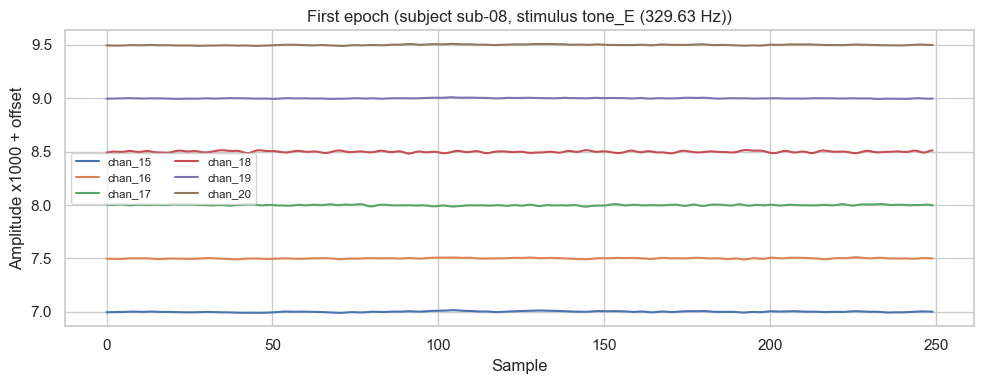

In [15]:

def load_epoch(row: pd.Series) -> np.ndarray:
    epochs_path = ROOT / row.epochs_file if not Path(row.epochs_file).is_absolute() else Path(row.epochs_file)
    arr = np.load(epochs_path)
    idx = int(row.epoch_idx)
    return arr[idx]


def plot_epoch(epoch: np.ndarray, channel_slice: slice = slice(0, 30), title: str = "", scale: float = 1000) -> None:
    fig, ax = plt.subplots(figsize=(10, 4))
    for channel_idx in range(*channel_slice.indices(epoch.shape[0])):
        offset = channel_idx * 0.5
        # Scale amplitude for visibility (EEG data is in V, scale to mV or uV)
        scaled = epoch[channel_idx] * scale + offset
        ax.plot(scaled, label=f"chan_{channel_idx + 1}")
    ax.set_title(title)
    ax.set_xlabel("Sample")
    ax.set_ylabel(f"Amplitude x{scale} + offset")
    ax.legend(ncol=2, fontsize="x-small")
    plt.tight_layout()

sample_row = epoch_index.iloc[0]
sample_epoch = load_epoch(sample_row)
plot_epoch(sample_epoch, channel_slice=slice(14, min(20, sample_epoch.shape[0])), title="First epoch (subject {}, stimulus {})".format(
    sample_row.subject_id, sample_row.stimulus_label
))


In [16]:

class_counts = epoch_index["stimulus_label"].value_counts()
class_counts


stimulus_label
tone_E (329.63 Hz)    33
tone_D (293.66 Hz)    33
tone_C (261.63 Hz)    32
Name: count, dtype: int64

Using SFREQ=250.0, TMIN=-0.2, onset sample in epoch=50
subjects: ['sub-01', 'sub-02', 'sub-05', 'sub-08']
stimuli (tones): ['tone_C', 'tone_D', 'tone_E']
ipywidgets not available — set SUBJECT and EPOCH_POS manually and run the cell to view


None

None

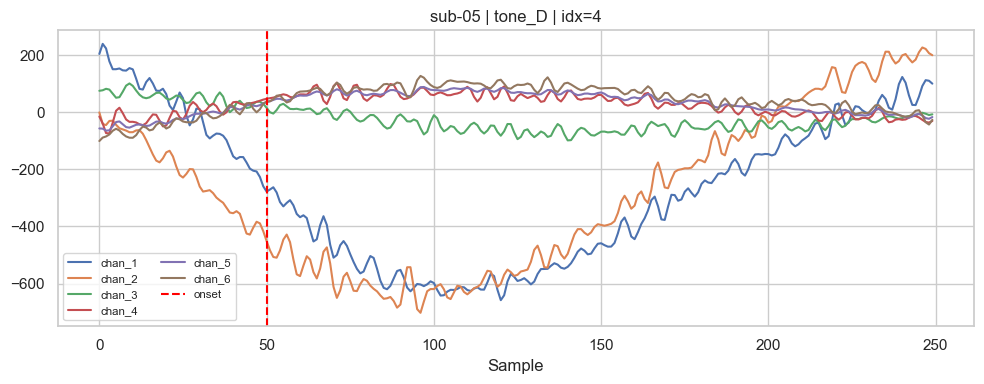

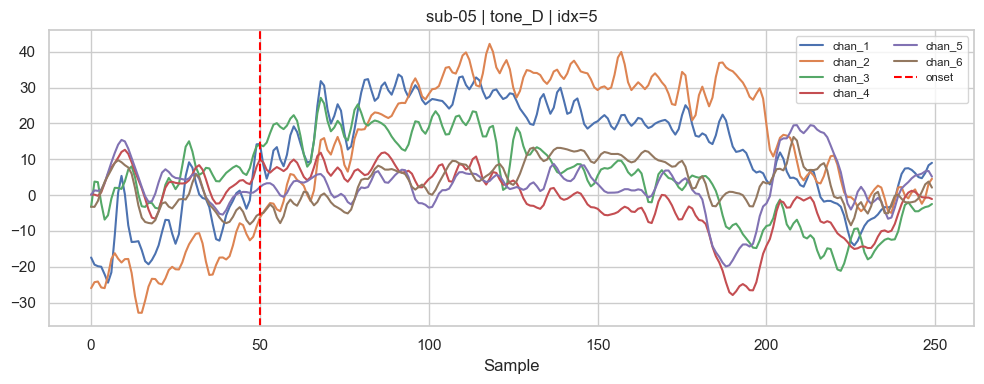

In [17]:
# Visualize epoch with stored onset sample
import yaml
from IPython.display import display



# Try to read epoching config to get tmin and sfreq; fall back to defaults
cfg_path = ROOT / "configs" / "yoto_preprocessing.yaml"
if cfg_path.exists():
    try:
        cfg = yaml.safe_load(cfg_path.read_text()) or {}
        epoch_cfg = cfg.get("preprocessing", {}).get("epoch", {}) if isinstance(cfg.get("preprocessing"), dict) else cfg.get("epoch", {})
    except Exception:
        epoch_cfg = {}
else:
    epoch_cfg = {}

SFREQ = float(epoch_cfg.get("resample_hz", epoch_cfg.get("sfreq", 250)))
TMIN = float(epoch_cfg.get("tmin", -0.2))
TMAX = float(epoch_cfg.get("tmax", 0.8))
ONSET_SAMPLE = int(round(-TMIN * SFREQ))

print(f"Using SFREQ={SFREQ}, TMIN={TMIN}, onset sample in epoch={ONSET_SAMPLE}")

# helper to plot epoch with onset marker
def plot_epoch_with_onset(epoch: np.ndarray, channel_slice: slice = slice(0, 6), title: str = "") -> None:
    fig, ax = plt.subplots(figsize=(10, 4))
    for channel_idx in range(*channel_slice.indices(epoch.shape[0])):
        offset = channel_idx * 0.5
        # scale to µV for visualization if values look small
        scaled = epoch[channel_idx] * 1e6 if abs(epoch).max() < 1e-2 else epoch[channel_idx]
        ax.plot(scaled + offset, label=f"chan_{channel_idx + 1}")
    ax.axvline(ONSET_SAMPLE, color="red", linestyle="--", label="onset")
    ax.set_title(title)
    ax.set_xlabel("Sample")
    ax.legend(ncol=2, fontsize="x-small")
    plt.tight_layout()

# interactive selector if ipywidgets available, otherwise provide simple pick variables
try:
    import ipywidgets as widgets
    from ipywidgets import interact
    has_widgets = True
except Exception:
    has_widgets = False

subjects = sorted(epoch_index['subject_id'].astype(str).unique().tolist())
stimuli = sorted(epoch_index['stimulus_id'].astype(str).unique().tolist())
print('subjects:', subjects)
print('stimuli (tones):', stimuli)

if has_widgets:
    def _view(subject, stimulus, sel_idx=0):
        group = epoch_index[(epoch_index['subject_id']==subject) & (epoch_index['stimulus_id']==stimulus)]
        if group.empty:
            print('No epochs for this selection')
            return
        row = group.iloc[sel_idx]
        epoch = load_epoch(row)
        plot_epoch_with_onset(epoch, channel_slice=slice(0, min(6, epoch.shape[0])), title=f"{subject} | {stimulus} | idx={row.epoch_idx}")

    # slider max is number of rows-1 per group, but for simplicity use a fixed range
    interact(_view, subject=widgets.Dropdown(options=subjects), stimulus=widgets.Dropdown(options=stimuli), sel_idx=widgets.IntSlider(min=0, max=10, step=1, value=0))
else:
    print('ipywidgets not available — set SUBJECT and EPOCH_POS manually and run the cell to view')
    # Example usage:
    def view_manual(subject: str, stimulus: str, pos_in_group: int = 0):
        group = epoch_index[(epoch_index['subject_id']==subject) & (epoch_index['stimulus_id']==stimulus)]
        if group.empty:
            print('No epochs for this selection')
            return
        if pos_in_group < 0 or pos_in_group >= len(group):
            print('pos_in_group out of range (0..{})'.format(len(group)-1))
            return
        row = group.iloc[pos_in_group]
        epoch = load_epoch(row)
        plot_epoch_with_onset(epoch, channel_slice=slice(0, min(6, epoch.shape[0])), title=f"{subject} | {stimulus} | idx={row.epoch_idx}")
    SUBJECT = 'sub-05'
    STIMULUS = 'tone_D'
    POS_IN_GROUP = 0  # pick 0..(n-1)
    display(view_manual(SUBJECT, STIMULUS, POS_IN_GROUP))
    SUBJECT = 'sub-05'
    STIMULUS = 'tone_D'
    POS_IN_GROUP = 1  # pick 0..(n-1)
    display(view_manual(SUBJECT, STIMULUS, POS_IN_GROUP))



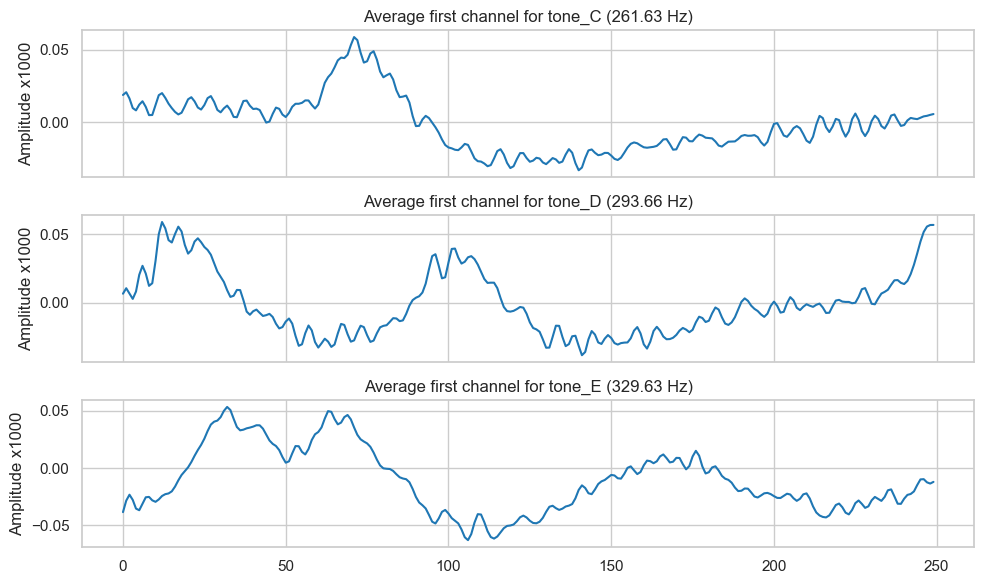

In [10]:

tone_averages = {}
for tone, group in epoch_index.groupby("stimulus_label"):
    samples = []
    for _, row in group.head(3).iterrows():
        samples.append(load_epoch(row))
    if samples:
        tone_averages[tone] = np.mean(samples, axis=0)

if tone_averages:
    fig, axes = plt.subplots(len(tone_averages), 1, figsize=(10, 2 * len(tone_averages)), sharex=True)
    if len(tone_averages) == 1:
        axes = [axes]
    for ax, (tone, avg) in zip(axes, tone_averages.items()):
        scale = 1000  # Scale EEG data for visibility
        ax.plot(avg[0] * scale, color="tab:blue")
        ax.set_title(f"Average first channel for {tone}")
        ax.set_ylabel(f"Amplitude x{scale}")
    plt.tight_layout()


In [11]:

base_epoch = load_epoch(epoch_index.iloc[0])
channel_stats = pd.DataFrame(
    {
        "mean": base_epoch.mean(axis=1),
        "std": base_epoch.std(axis=1),
    }
)
channel_stats.index = [f"chan_{i + 1}" for i in channel_stats.index]
channel_stats.head()


,mean,std
chan_1,-0.000006,0.000072
chan_2,-0.000006,0.000078
chan_3,-0.000002,0.000016
chan_4,-0.000002,0.000012
chan_5,-0.000003,0.000015


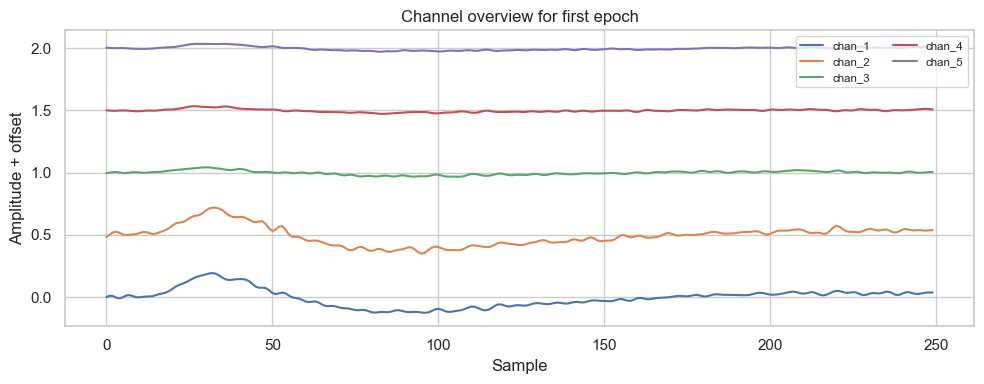

In [ ]:

amplitude_scale = 1000  # Multiply signal amplitude (try 1, 10, 100, 1000, etc.)
offset_scale = 0.5      # Vertical spacing between channels

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(min(5, base_epoch.shape[0])):
    ax.plot(base_epoch[i] * amplitude_scale + i * offset_scale, label=f"chan_{i + 1}")
ax.set_title("Channel overview for first epoch")
ax.set_xlabel("Sample")
ax.set_ylabel("Amplitude + offset")
ax.legend(ncol=2, fontsize="x-small")
plt.tight_layout()


Channels (30): ['FP1', 'FP2', 'F7', 'F3', 'FZ', 'F4', 'F8', 'FT7', 'FC3', 'FCZ']...
Numbered labels (first 10): ['1 FP1', '2 FP2', '3 F7', '4 F3', '5 FZ', '6 F4', '7 F8', '8 FT7', '9 FC3', '10 FCZ']


/var/folders/08/z93r2k0j68b5v62w7wz4p3500000gn/T/ipykernel_94074/2775103623.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


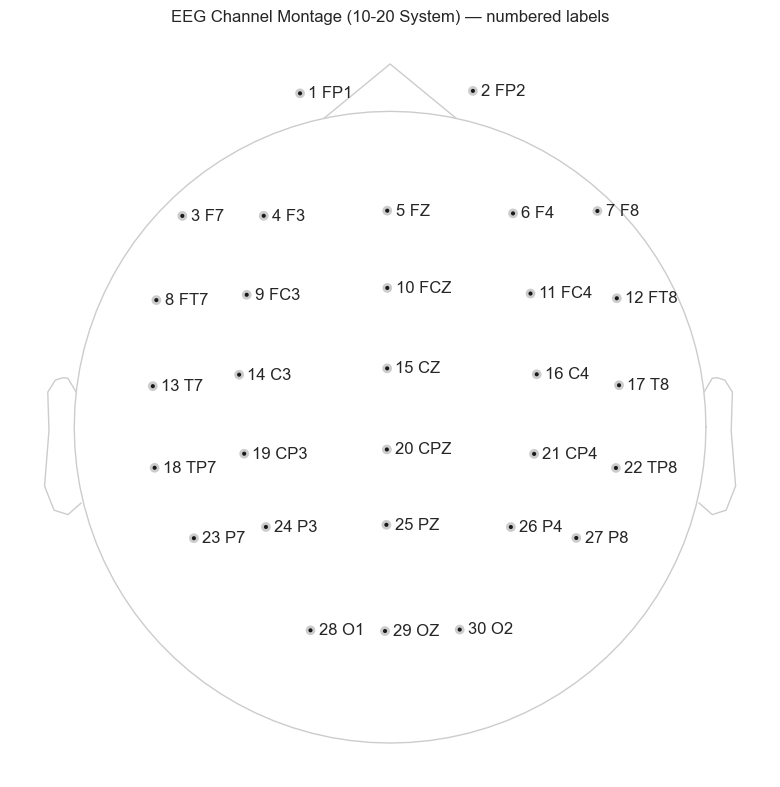

In [26]:
import mne
import matplotlib.pyplot as plt

sample_vhdr = DATA_ROOT / "raw_samples/ds005815/sub-01/ses-1/eeg/sub-01_ses-1_task-task_eeg.vhdr"
raw = mne.io.read_raw_brainvision(sample_vhdr, preload=False, verbose=False)

# Attach a standard 10-20 montage (the file lacks digitized positions)
montage = mne.channels.make_standard_montage("standard_1020")
raw_mont = raw.copy().set_montage(montage, match_case=False, on_missing="ignore")

# Create numbered channel labels (1, 2, 3, ...)
ch_names = raw_mont.ch_names
num_labels = [f"{i+1} {n}" for i, n in enumerate(ch_names)]
print(f"Channels ({len(ch_names)}): {ch_names[:10]}...")
print(f"Numbered labels (first 10): {num_labels[:10]}")

# Rename channels on a plotting copy so original `raw` stays unchanged
rename_map = {orig: new for orig, new in zip(ch_names, num_labels)}
plot_raw = raw_mont.copy()
plot_raw.rename_channels(rename_map)

fig = plot_raw.plot_sensors(show_names=True, show=False, sphere=(0, 0, 0, 0.095))
fig.set_size_inches(8, 8)
plt.title("EEG Channel Montage (10-20 System) — numbered labels")
plt.tight_layout()
plt.show()

In [20]:

def search_epochs(df: pd.DataFrame, query: str) -> pd.DataFrame:
    if not query:
        return df.iloc[:0]
    mask = (
        df["subject_id"].str.contains(query, case=False, na=False)
        | df["stimulus_label"].str.contains(query, case=False, na=False)
        | df["source_file"].str.contains(query, case=False, na=False)
    )
    return df[mask]

search_epochs(epoch_index, "tone_D").head()


,dataset_id,subject_id,source_file,epochs_file,epoch_idx,stimulus_id,n_channels,n_samples,stimulus_label
1,ds005815,sub-01,data/raw_samples/ds005815/sub-01/ses-1/eeg/sub...,data/processed/epochs_yoto_tones/ds005815__sub...,1,tone_D,30,250,tone_D (293.66 Hz)
2,ds005815,sub-01,data/raw_samples/ds005815/sub-01/ses-1/eeg/sub...,data/processed/epochs_yoto_tones/ds005815__sub...,2,tone_D,30,250,tone_D (293.66 Hz)
5,ds005815,sub-01,data/raw_samples/ds005815/sub-01/ses-1/eeg/sub...,data/processed/epochs_yoto_tones/ds005815__sub...,5,tone_D,30,250,tone_D (293.66 Hz)
15,ds005815,sub-01,data/raw_samples/ds005815/sub-01/ses-1/eeg/sub...,data/processed/epochs_yoto_tones/ds005815__sub...,15,tone_D,30,250,tone_D (293.66 Hz)
16,ds005815,sub-01,data/raw_samples/ds005815/sub-01/ses-1/eeg/sub...,data/processed/epochs_yoto_tones/ds005815__sub...,16,tone_D,30,250,tone_D (293.66 Hz)
